## Import Required Libraries

In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# sklearn packages
from sklearn.preprocessing import (StandardScaler, 
                                    MinMaxScaler)

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split

from sklearn.metrics import (accuracy_score, 
                            classification_report, 
                            confusion_matrix, 
                            ConfusionMatrixDisplay)


# MNE Packages
import mne
from mne.datasets.sleep_physionet.age import fetch_data
mne.utils.set_config('MNE_USE_CUDA', 'true')

## Step -1 Loading the Data

In [2]:
# Notes : Based on PTP the signal are automatically dropped in mne while reading the epoch level

In [3]:
class EEGEpochExtractor:
    def __init__(self, data_dir):
        """
        Initialize the extractor with the directory containing EDF files.
        """
        self.data_dir = data_dir
        self.all_epochs = []

    # --- Trail classification ---
    @staticmethod
    def trail_classification(trail_num: int) -> str:
        if trail_num in [4, 6, 8, 10, 12, 14]:
            return "imaginary"
        elif trail_num in [1, 2]:
            return "baseline"
        else:
            return "motor"

    # --- Event type classification ---
    @staticmethod
    def event_type_classification(trail_num: int):
        if trail_num in [1, 2]:
            return ("rest", "NA", "NA")
        elif trail_num in [3, 4, 7, 8, 11, 12]:
            return ("rest", "left_fist", "right_fist")
        elif trail_num in [5, 6, 9, 10, 13, 14]:
            return ("rest", "both_fist", "both_feet")

    # --- Metadata extraction ---
    def extract_metadata(self) -> pd.DataFrame:
        metadata = []

        for subj in sorted(os.listdir(self.data_dir)):
            subj_path = os.path.join(self.data_dir, subj)
            if not os.path.isdir(subj_path):
                continue

            for file in sorted(os.listdir(subj_path)):
                if file.endswith(".edf") and not file.endswith(".edf.event"):
                    match = re.search(r"R(\d{2})\.edf$", file)
                    if match:
                        trial_num = int(match.group(1))
                        trail_type = self.trail_classification(trial_num)
                        event_type = self.event_type_classification(trial_num)

                        edf_file = os.path.join(subj_path, file)
                        event_file = edf_file + ".event" if os.path.exists(edf_file + ".event") else None

                        metadata.append({
                            "subject": subj,
                            "trial": trial_num,
                            "trail_type": trail_type,
                            "edf_file": edf_file,
                            "event_file": event_file,
                            "T0": event_type[0],
                            "T1": event_type[1],
                            "T2": event_type[2],
                        })

        self.metadata_df = pd.DataFrame(metadata)
        return self.metadata_df


    def process_file(self, file_path, event_id_mapping):
        """
        Process a single EDF file and return epochs.
        """
        print(f"Processing: {file_path}")
        raw_edf = mne.io.read_raw_edf(file_path, preload=True)
        annotations_edf = mne.read_annotations(file_path)

        # Update annotation descriptions
        new_descriptions = [
            event_id_mapping.get(desc, desc) for desc in annotations_edf.description
        ]
        annotations_edf.description = new_descriptions
        
        # Set updated annotations
        raw_edf.set_annotations(annotations_edf)
        
        # Convert annotations to events
        events, event_id = mne.events_from_annotations(raw_edf)
        
        
        epochs = mne.Epochs(
            raw=raw_edf,
            events=events,
            event_id= event_id,
            reject = None,
            flat = None, 
            reject_by_annotation= False, 
            baseline=None,
            preload=True
        )
        return epochs

    def process_all(self):
        """
        Process all EDF files in the directory and store their epochs.
        """
        metadata_info = self.extract_metadata() # Metadata Information
        self.all_epochs = []  # reset list
        for filename in metadata_info["edf_file"].tolist():
            if filename.endswith(".edf"):
                event_id_mapping = {"T0": metadata_info[(metadata_info["edf_file"]==filename)]["T0"].values[0], 
                                    "T1": metadata_info[(metadata_info["edf_file"]==filename)]["T1"].values[0], 
                                    "T2": metadata_info[(metadata_info["edf_file"]==filename)]["T2"].values[0]}
                print(event_id_mapping)
                epochs = self.process_file(file_path=filename, event_id_mapping= event_id_mapping)
                self.all_epochs.append(epochs)
        
        print(f"\nTotal EDF files processed: {len(self.all_epochs)}")
        return self.all_epochs


In [4]:
extractor = EEGEpochExtractor(data_dir= "../data/Original/")
all_epochs = extractor.process_all()

{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R01.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R01.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 9759  =      0.000 ...    60.994 secs...
Used Annotations descriptions: [np.str_('rest')]
Not setting metadata
1 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 1 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'NA', 'T2': 'NA'}
Processing: ../data/Original/S001/S001R02.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R02.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S001/S001R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S001/S001R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S001/S001R10.edf
Extracting EDF parameters from /User

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S002/S002R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S002/S002R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dro

...

Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S107/S107R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S107/S107R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19999  =      0.000 ...   124.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S108/S108R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S108/S108R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dro

/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/3325446389.py:85: RuntimeWarning: All epochs were dropped!
You might need to alter reject/flat-criteria or drop bad channels to avoid this. You can use Epochs.plot_drop_log() to see which channels are responsible for the dropping of epochs.
  epochs = mne.Epochs(


Used Annotations descriptions: [np.str_('left_fist'), np.str_('rest'), np.str_('right_fist')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dropped
{'T0': 'rest', 'T1': 'both_fist', 'T2': 'both_feet'}
Processing: ../data/Original/S109/S109R09.edf
Extracting EDF parameters from /Users/kavisanthoshkumar/Library/CloudStorage/OneDrive-IllinoisInstituteofTechnology/Tensorflow/PhysicoNet/data/Original/S109/S109R09.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 19679  =      0.000 ...   122.994 secs...
Used Annotations descriptions: [np.str_('both_feet'), np.str_('both_fist'), np.str_('rest')]
Not setting metadata
30 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 30 events and 113 original time points ...
1 bad epochs dro

## Step -2 : Feature Extraction - Time Frequency Representations

In [5]:
# Frequency bands range in Hz for EEG
FREQ_BANDS = {
    "delta": [0.5, 4.5],
    "theta": [4.5, 8.5],
    "alpha": [8.5, 11.5],
    "sigma": [11.5, 15.5],
    "beta": [15.5, 30],
}

In [6]:
def eeg_tfr_bandpower(epochs, freq_bands=FREQ_BANDS, n_cycles=None, time_bandwidth=4):
    """
    Compute TFR and extract mean power in predefined frequency bands for each EEG epoch.
    
    Parameters
    ----------
    epochs : mne.Epochs
        Preprocessed EEG epochs
    freq_bands : dict
        Frequency bands to average (e.g., delta, theta, alpha, sigma, beta)
    n_cycles : float or array
        Number of cycles for multitaper wavelet. If None, defaults to freq/2.
    time_bandwidth : float
        Time bandwidth parameter for multitaper method.
    
    Returns
    -------
    X_band : np.ndarray
        Shape (n_epochs, n_channels * n_bands)
    """
    
    # Define frequencies for TFR computation
    freqs = np.linspace(0.5, 30, 60)  # fine resolution
    if n_cycles is None:
        n_cycles = freqs / 2.0

    # Compute TFR
    tfr = epochs.compute_tfr(method = "multitaper", freqs=freqs, n_cycles=n_cycles, time_bandwidth=time_bandwidth,
                         return_itc=False, average=False, picks='eeg', decim=1, n_jobs=-1)
    
    # Extract power
    tfr_data = tfr.data  # shape: (n_epochs, n_channels, n_freqs, n_times)
    
    # Average over time
    tfr_data_mean = tfr_data.mean(axis=-1)  # shape: (n_epochs, n_channels, n_freqs)
    
    # Initialize feature list
    X_band = []
    
    # Loop over each band and compute mean power
    for fmin, fmax in freq_bands.values():
        band_mask = (tfr.freqs >= fmin) & (tfr.freqs < fmax)
        band_power = tfr_data_mean[:, :, band_mask].mean(axis=-1)  # mean over frequency
        X_band.append(band_power.reshape(len(band_power), -1))
    
    # Concatenate all bands
    X_band = np.concatenate(X_band, axis=1)  # shape: (n_epochs, n_channels * n_bands)
    
    return X_band

In [7]:
# Iterate over the 30 seconds epochs, calculate the proper powerband features
# Then define the right id for the "group" which should be the participant_id

X = []
y = []
groups = []
for group_id, epochs in enumerate(all_epochs):
  try:
    print(f"Processing participants #{group_id}")

    X_epoch = eeg_tfr_bandpower(epochs)
    y_epoch_event_mapping = epochs.event_id
    y_epoch = epochs.events[:, 2]

    # y_epoch into a categorical variable
    y_epoch = np.array(y_epoch, dtype = object)
    for key, value in y_epoch_event_mapping.items():
        y_epoch[y_epoch == value] = str(key)

    y_epoch = list(y_epoch)

    group_epoch = [group_id]*len(y_epoch)

    X.append(X_epoch)
    y.append(y_epoch)
    groups.append(group_epoch)
  except:
    print(f"Error Processing Participants #{group_id}")

# Transform these lists into numpy array with proper size for sklearn models
X = np.concatenate(X, axis=0)
y = np.concatenate(y, axis=0)
groups = np.concatenate(groups, axis=0)

Processing participants #0


/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/2943966233.py:28: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  tfr = epochs.compute_tfr(method = "multitaper", freqs=freqs, n_cycles=n_cycles, time_bandwidth=time_bandwidth,
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    2.3s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    2.4s finished
/var/folders/_p/pgtp_zhj7n3717r3m0prtkdh0000gn/T/ipykernel_80219/2943966233.py:28: RuntimeWarning: epochs._get_data() can't run because this Epochs-object is empty. You might want to check Epochs.drop_log or Epochs.plot_drop_log() to see why epochs were dropped.
  tfr = epochs.compute_tfr(method = "multitaper", freqs=freqs, n_cycles=n_cycles, time_bandwidth=time_bandwidth,
[Parallel(n_jobs=-1)]: Using backend L

Error Processing Participants #0
Processing participants #1
Error Processing Participants #1
Processing participants #2


[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.1s
[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.1s


Processing participants #3


...

[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.4s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.1s


Processing participants #1524


[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 11 concurrent workers.
[Parallel(n_jobs=-1)]: Done   7 tasks      | elapsed:    0.1s


Processing participants #1525


[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:    0.4s finished


In [10]:
Y_CAT_MAPPING = {"rest" : 0,
                "both_feet" : 1, 
                "both_fist" : 2, 
                "left_fist" : 3, 
                "right_fist" : 4}

for key, value in Y_CAT_MAPPING.items():
        y[y == key] = value

## Step 3 : Train, Valid and Test Splits

In [11]:
train_len = int(np.floor(np.unique(groups).shape[0] * 0.80))
valid_len = int(np.floor(np.unique(groups).shape[0] * 0.10))
test_len = int(np.unique(groups).shape[0] - (train_len+valid_len))
print(f"Train : {train_len}, Valid : {valid_len} and Test : {test_len}")
train_groups = np.random.choice(groups, size = train_len, replace = False)
valid_groups = np.random.choice(groups, size = valid_len, replace = False)
test_groups = np.random.choice(groups, size = test_len, replace = False)

# Generate the train and Valid sets
X_train, X_valid = X[np.isin(groups, train_groups)], X[np.isin(groups, valid_groups)]
y_train, y_valid = y[np.isin(groups, train_groups)], y[np.isin(groups, valid_groups)]

X_test = X[np.isin(groups, test_groups)]
y_test = y[np.isin(groups, test_groups)]

print("Shape of X_train Dataset", X_train.shape)
print("Shape of y_train Dataset", y_train.shape)
print("Shape of X_valid Dataset", X_valid.shape)
print("Shape of y_valid Dataset", y_valid.shape)
print("Shape of X_test Dataset", X_test.shape)
print("Shape of y_test Dataset", y_test.shape)


Train : 1046, Valid : 130 and Test : 132
Shape of X_train Dataset (21059, 320)
Shape of y_train Dataset (21059,)
Shape of X_valid Dataset (3633, 320)
Shape of y_valid Dataset (3633,)
Shape of X_test Dataset (3693, 320)
Shape of y_test Dataset (3693,)


In [12]:
np.savez("../data/mne_tfr/train.npz", X_train, y_train)
np.savez("../data/mne_tfr/valid.npz", X_valid, y_valid)
np.savez("../data/mne_tfr/test.npz", X_test, y_test)

In [2]:
TRAIN_FILE_PATH = "../data/mne_tfr/train.npz"
VALID_FILE_PATH = "../data/mne_tfr/valid.npz"
TEST_FILE_PATH = "../data/mne_tfr/test.npz"

In [3]:
# Train
train = np.load(TRAIN_FILE_PATH)
X_train, y_train = train["arr_0"], train["arr_1"].astype(int)

# Valid
valid = np.load(VALID_FILE_PATH)
X_valid, y_valid = valid["arr_0"], valid["arr_1"].astype(int)

X, y = np.vstack([X_train, X_valid]), np.hstack([y_train, y_valid])

# Test
test = np.load(TEST_FILE_PATH)
X_test, y_test = test["arr_0"], test["arr_1"].astype(int)

print(f"Shape of X_train : {X_train.shape} and y_train : {y_train.shape}")
print(f"Shape of X_val : {X_valid.shape} and y_valid : {y_valid.shape}")
print(f"Shape of X_test : {X_test.shape} and y_test : {y_test.shape}")

Shape of X_train : (21059, 320) and y_train : (21059,)
Shape of X_val : (3633, 320) and y_valid : (3633,)
Shape of X_test : (3693, 320) and y_test : (3693,)


In [4]:
X = X[(y != 0)]
X_test = X_test[(y_test != 0)]

In [5]:
y = y[(y != 0)]
y_test = y_test[(y_test != 0)]

## Step 4 : Random Forest Model

In [6]:
def tune_random_forest_full(X, y, n_iter=20, random_state=42):
    """
    Tune RandomForestClassifier using RandomizedSearchCV on the full dataset
    and return the best model trained on all data.

    Parameters:
    -----------
    X : array-like
        Feature matrix.
    y : array-like
        Target labels.
    n_iter : int, optional
        Number of random parameter combinations to try. Default = 20
    random_state : int, optional
        Seed for reproducibility. Default = 42

    Returns:
    --------
    best_model : RandomForestClassifier
        Random Forest model trained on the full dataset with best hyperparameters.
    """

    # --- Base Random Forest --- #
    rf = RandomForestClassifier(random_state=random_state)

    # --- Parameter space --- #
    param_distributions = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [None, 10, 20, 30, 40],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'max_features': ['sqrt', 'log2', None],
    }

    # --- Randomized Search with 5-fold CV --- #
    rf_random = RandomizedSearchCV(
        estimator=rf,
        param_distributions=param_distributions,
        n_iter=n_iter,
        cv=5,                   # cross-validation folds
        verbose=2,
        random_state=random_state,
        n_jobs=-1
    )

    # --- Fit search on full dataset --- #
    rf_random.fit(X, y)

    # --- Return the best model trained on all data --- #
    best_model = rf_random.best_estimator_
    print(rf_random.best_estimator_)
    best_model.fit(X, y)  # retrain on full dataset
    return best_model

best_rf = tune_random_forest_full(X, y, n_iter=2)

Fitting 5 folds for each of 2 candidates, totalling 10 fits
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.2min
[CV] END max_depth=40, max_features=sqrt, min_samples_leaf=1, min_samples_split=2, n_estimators=500; total time= 1.3min
[CV] END max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time= 8.9min
[CV] END max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimators=300; total time= 9.0min
[CV] END max_depth=None, max_features=None, min_samples_leaf=4, min_samples_split=5, n_estimator

#### Step 4.1 Train Predictions

              precision    recall  f1-score   support

           1       1.00      1.00      1.00      3215
           2       1.00      1.00      1.00      3183
           3       1.00      1.00      1.00      3213
           4       1.00      1.00      1.00      3159

    accuracy                           1.00     12770
   macro avg       1.00      1.00      1.00     12770
weighted avg       1.00      1.00      1.00     12770



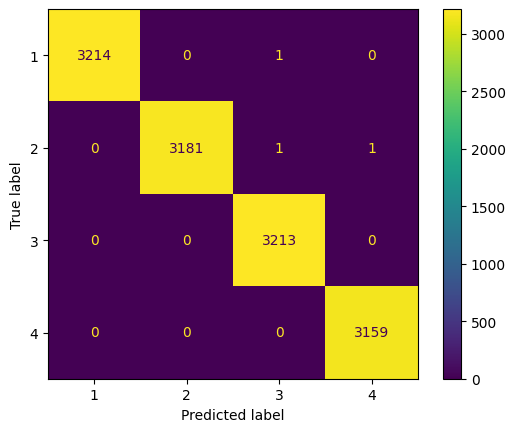

In [7]:
y_train_pred = best_rf.predict(X)
# Confusion Matrix
cm = confusion_matrix(y, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y, y_train_pred))

#### Step 4.2 Test Predictions

              precision    recall  f1-score   support

           1       0.70      0.74      0.72       442
           2       0.70      0.78      0.74       444
           3       0.79      0.75      0.77       515
           4       0.80      0.73      0.76       509

    accuracy                           0.75      1910
   macro avg       0.75      0.75      0.75      1910
weighted avg       0.75      0.75      0.75      1910



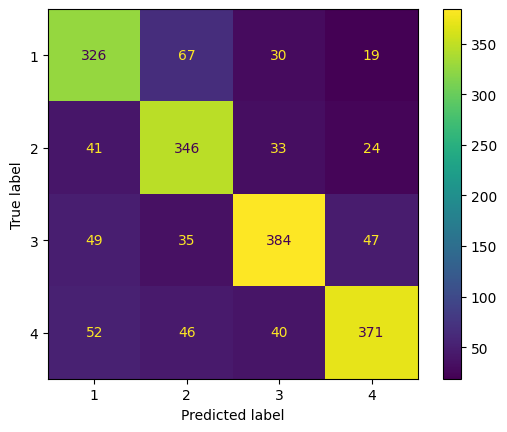

In [9]:
y_pred = best_rf.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_rf.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))

## Step 5 : SVM Model

In [10]:
sc = StandardScaler()
sc.fit(X)

# Scale the Train Dataset
X = sc.transform(X)
X_test = sc.transform(X_test)

In [11]:
from sklearn.model_selection import StratifiedShuffleSplit, RandomizedSearchCV, train_test_split
from sklearn.svm import SVC

# --- Parameter ranges (smaller but effective) --- #
C_range = np.logspace(-2, 4, 7)
gamma_range = np.logspace(-6, 1, 7)
param_grid = dict(C=C_range, gamma=gamma_range)

# --- Cross-validation setup --- #
cv = StratifiedShuffleSplit(n_splits=5, test_size=0.2, random_state=42)

# --- Use a subset for faster tuning --- #
X_sub, _, y_sub, _ = train_test_split(
    X, y, train_size=5000, stratify=y, random_state=42
)

# --- Randomized Search with parallelization --- #
grid = RandomizedSearchCV(
    SVC(kernel='rbf'),
    param_distributions=param_grid,
    n_iter=20,            # sample only 20 parameter combinations
    cv=cv,
    n_jobs=-1,            # use all CPU cores
    random_state=42,
    verbose=1
)

# --- Fit on the subset --- #
grid.fit(X_sub, y_sub)

print("Best parameters:", grid.best_params_)
print("Best CV score: %.2f" % grid.best_score_)

# --- Retrain final model on full data --- #
best_model = SVC(kernel='rbf', **grid.best_params_)
best_model.fit(X, y)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best parameters: {'gamma': np.float64(0.00021544346900318845), 'C': np.float64(10000.0)}
Best CV score: 0.39


SVC(C=np.float64(10000.0), gamma=np.float64(0.00021544346900318845))

#### Step 4.1 Train Predictions

              precision    recall  f1-score   support

           1       0.73      0.62      0.67      3215
           2       0.75      0.63      0.68      3183
           3       0.73      0.68      0.70      3213
           4       0.54      0.76      0.63      3159

    accuracy                           0.67     12770
   macro avg       0.69      0.67      0.67     12770
weighted avg       0.69      0.67      0.67     12770



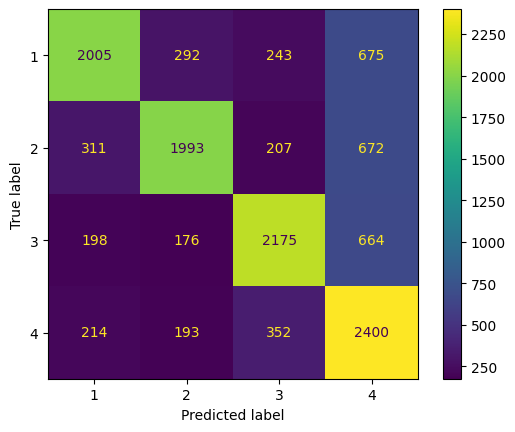

In [12]:
y_train_pred = best_model.predict(X)
# Confusion Matrix
cm = confusion_matrix(y, y_train_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y, y_train_pred, ))

#### Step 4.2 Test Predictions

              precision    recall  f1-score   support

           1       0.52      0.46      0.49       442
           2       0.55      0.47      0.51       444
           3       0.62      0.60      0.61       515
           4       0.50      0.62      0.55       509

    accuracy                           0.54      1910
   macro avg       0.55      0.54      0.54      1910
weighted avg       0.55      0.54      0.54      1910



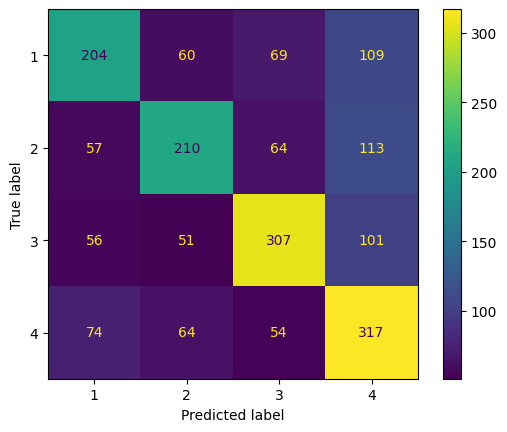

In [13]:
y_pred = best_model.predict(X_test)
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot() # will appear at the end of the output
print(classification_report(y_test, y_pred, ))